In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [52]:
df=pd.read_csv('Data.csv')

In [53]:
df

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,140295
1,NaN,TA,119007
2,TA,TA,136737
3,TA,TA,109913
4,Gd,TA,177281
...,...,...,...
795,NaN,TA,144226
796,NaN,TA,173308
797,NaN,Gd,89348
798,NaN,Gd,134397


In [24]:
df.sample(10)

,FireplaceQu,GarageQual,SalePrice
505,Gd,Fa,211707
48,TA,TA,202846
373,NaN,TA,550000
751,Fa,TA,229050
678,NaN,TA,82488
321,TA,Fa,244869
480,NaN,TA,231721
346,NaN,TA,127779
692,TA,TA,478012
787,TA,TA,145179


In [25]:
df.isnull().mean()*100

FireplaceQu    47.25
GarageQual      5.50
SalePrice       0.00
dtype: float64

Text(0, 0.5, 'Number of house')

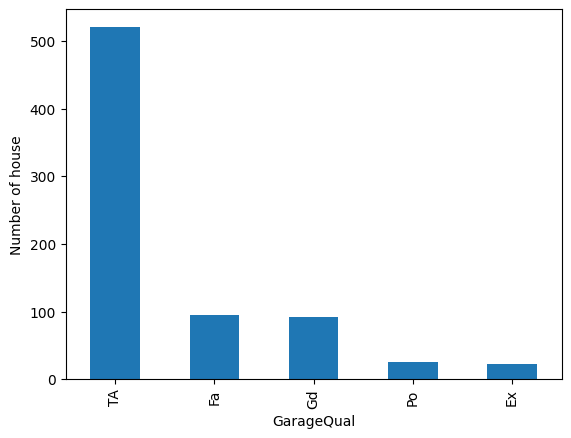

In [26]:
df['GarageQual'].value_counts().sort_values(ascending=False).plot.bar()
plt.xlabel('GarageQual')
plt.ylabel('Number of house')

In [29]:
temp=df[df['GarageQual']=='TA']['SalePrice']

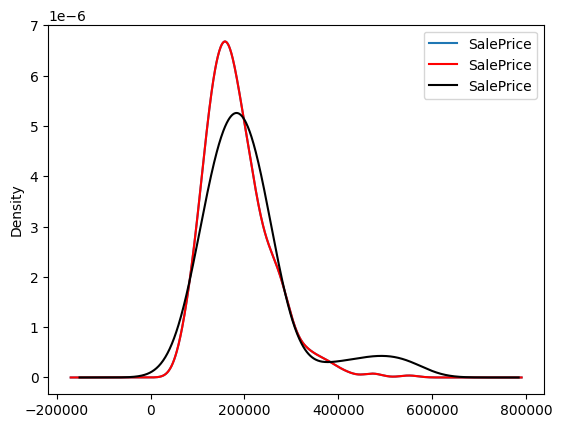

In [30]:
fig=plt.figure()
ax=fig.add_subplot(111)
temp.plot(kind='kde',ax=ax)
df[df['GarageQual']=='TA']['SalePrice'].plot(kind='kde',ax=ax,color='red')
df[df['GarageQual'].isnull()]['SalePrice'].plot(kind='kde',ax=ax,color='black')
plt.legend()


In [31]:
df['GarageQual'].mode()    #mode

0    TA
Name: GarageQual, dtype: object

In [32]:
# SO MODE IS TA
df['GarageQual'].fillna('TA')

0      TA
1      TA
2      TA
3      TA
4      TA
       ..
795    TA
796    TA
797    Gd
798    Gd
799    Fa
Name: GarageQual, Length: 800, dtype: object

<Axes: xlabel='GarageQual'>

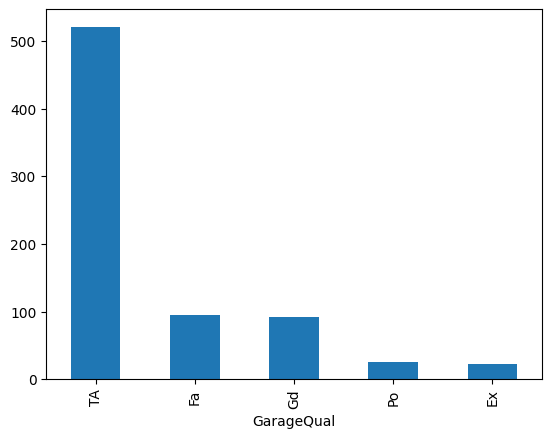

In [33]:
df['GarageQual'].value_counts().plot(kind='bar')

In [17]:
df['GarageQual'].isnull().sum()

np.int64(0)

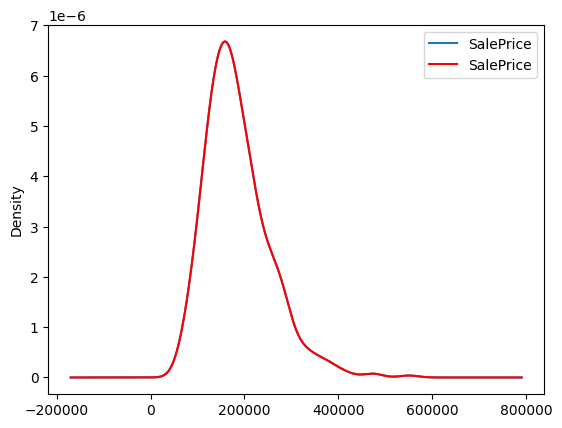

In [34]:
fig=plt.figure()
ax=fig.add_subplot(111)
temp.plot(kind='kde',ax=ax)
df[df['GarageQual']=='TA']['SalePrice'].plot(kind='kde',ax=ax,color='red')
plt.legend()                   # now see the value of garagequal before and after the fill na value not change because the missing value is vry small

In [35]:
#same for other fireplace col also

now using sklearn

In [36]:
from sklearn.model_selection import train_test_split

In [38]:
x_train,x_test,y_train,y_test=train_test_split(df.drop(columns=['SalePrice']),df['SalePrice'],test_size=0.2,random_state=42)

In [39]:
from sklearn.impute import SimpleImputer

In [40]:
imputer=SimpleImputer(strategy='most_frequent')

In [49]:
x_train=imputer.fit_transform(x_train)
x_test=imputer.fit_transform(x_test)

In [50]:
imputer.statistics_

array(['TA', 'TA'], dtype=object)